# Deliverable D3: Exploratory Data Analysis & Visualisations

This notebook contains a comprehensive exploration of the mutual fund portfolio datasets, featuring 16 different plots and 10 key business insights.

In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
db_path = os.path.join("..", "data", "db", "bluestock_mf.db")
conn = sqlite3.connect(db_path)

### 1. NAV Daily Trend Analysis (2022–2026)
Highlighting the 2023 bull run and 2024 market corrections.

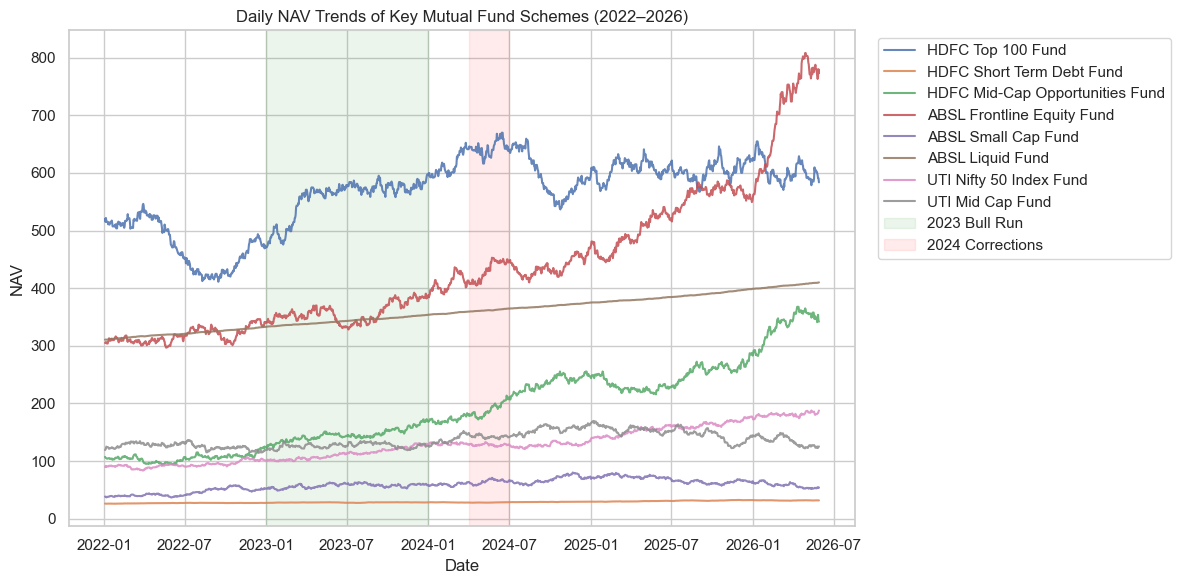

In [2]:
df_nav = pd.read_sql_query("""
    SELECT n.date, f.scheme_name, n.nav, f.category
    FROM fact_nav n
    JOIN dim_fund f ON n.amfi_code = f.amfi_code
""", conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])

plt.figure(figsize=(12, 6))
schemes_to_plot = df_nav['scheme_name'].unique()[:8]
for scheme in schemes_to_plot:
    subset = df_nav[df_nav['scheme_name'] == scheme].sort_values('date')
    plt.plot(subset['date'], subset['nav'], label=scheme.split(' - ')[0], alpha=0.85, linewidth=1.5)

plt.axvspan(pd.to_datetime('2023-01-01'), pd.to_datetime('2023-12-31'), color='green', alpha=0.08, label='2023 Bull Run')
plt.axvspan(pd.to_datetime('2024-04-01'), pd.to_datetime('2024-06-30'), color='red', alpha=0.08, label='2024 Corrections')

plt.title("Daily NAV Trends of Key Mutual Fund Schemes (2022–2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2. AUM Growth by Fund House (2022–2025)
Highlighting SBI Mutual Fund's dominance.

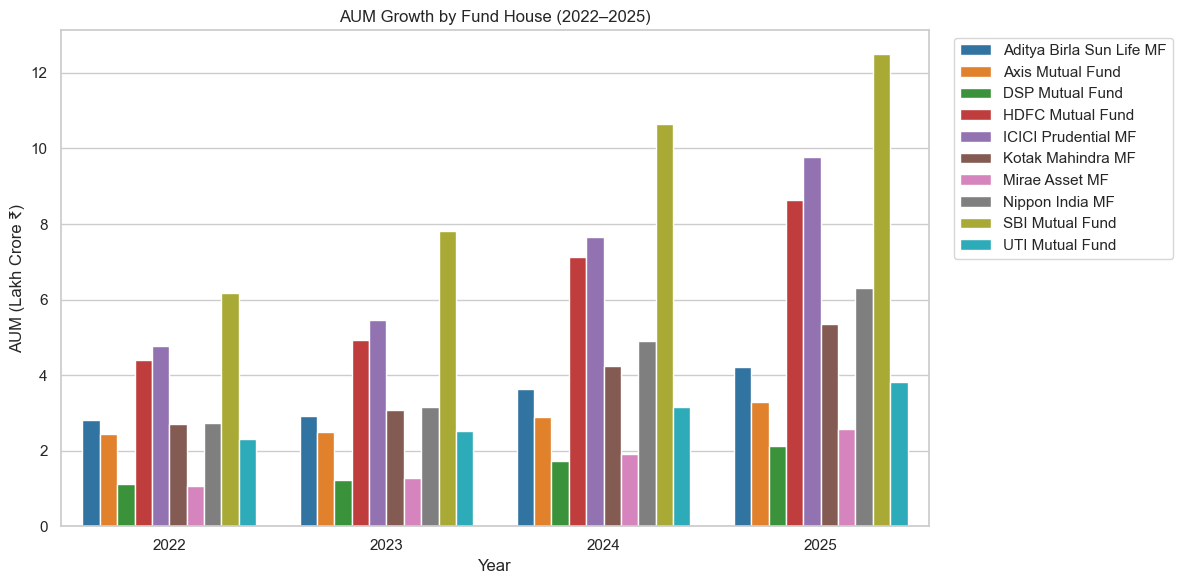

In [3]:
df_aum = pd.read_sql_query("SELECT date, fund_house, aum_crore FROM fact_aum", conn)
df_aum['year'] = pd.to_datetime(df_aum['date']).dt.year
aum_yearly = df_aum.groupby(['year', 'fund_house'])['aum_crore'].mean().reset_index()
aum_yearly['aum_lakh_crore'] = aum_yearly['aum_crore'] / 100000

plt.figure(figsize=(12, 6))
sns.barplot(data=aum_yearly, x='year', y='aum_lakh_crore', hue='fund_house', palette="tab10")
plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3. SIP Inflow Monthly Trend (Jan 2022 – Dec 2025)
Annotating the ₹31,002 Cr peak in Dec 2025.

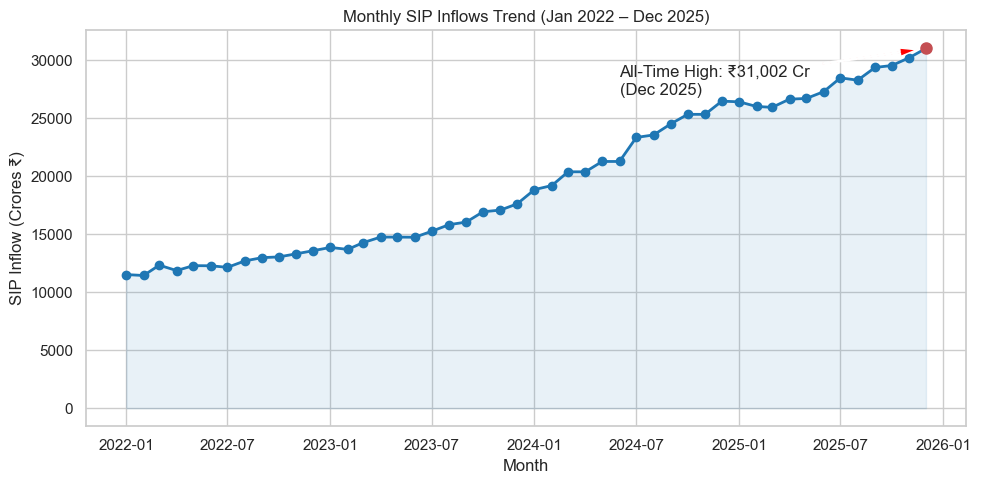

In [4]:
df_sip = pd.read_sql_query("SELECT month, sip_inflow_crore FROM fact_monthly_sip_inflows", conn)
df_sip['date'] = pd.to_datetime(df_sip['month'] + '-01')

plt.figure(figsize=(10, 5))
plt.plot(df_sip['date'], df_sip['sip_inflow_crore'], color="#1f77b4", marker='o', linewidth=2)
plt.fill_between(df_sip['date'], df_sip['sip_inflow_crore'], color="#1f77b4", alpha=0.1)

peak_row = df_sip.sort_values('date').iloc[-1]
plt.plot(peak_row['date'], peak_row['sip_inflow_crore'], 'ro', markersize=8)
plt.annotate(f"All-Time High: ₹{int(peak_row['sip_inflow_crore']):,} Cr\n(Dec 2025)", 
             xy=(peak_row['date'], peak_row['sip_inflow_crore']), 
             xytext=(pd.to_datetime('2024-06-01'), 27000),
             arrowprops=dict(facecolor='red', shrink=0.08, width=1, headwidth=6))

plt.title("Monthly SIP Inflows Trend (Jan 2022 – Dec 2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crores ₹)")
plt.tight_layout()
plt.show()

### 4. Category Inflow Heatmap
Months on X-axis, fund categories on Y-axis.

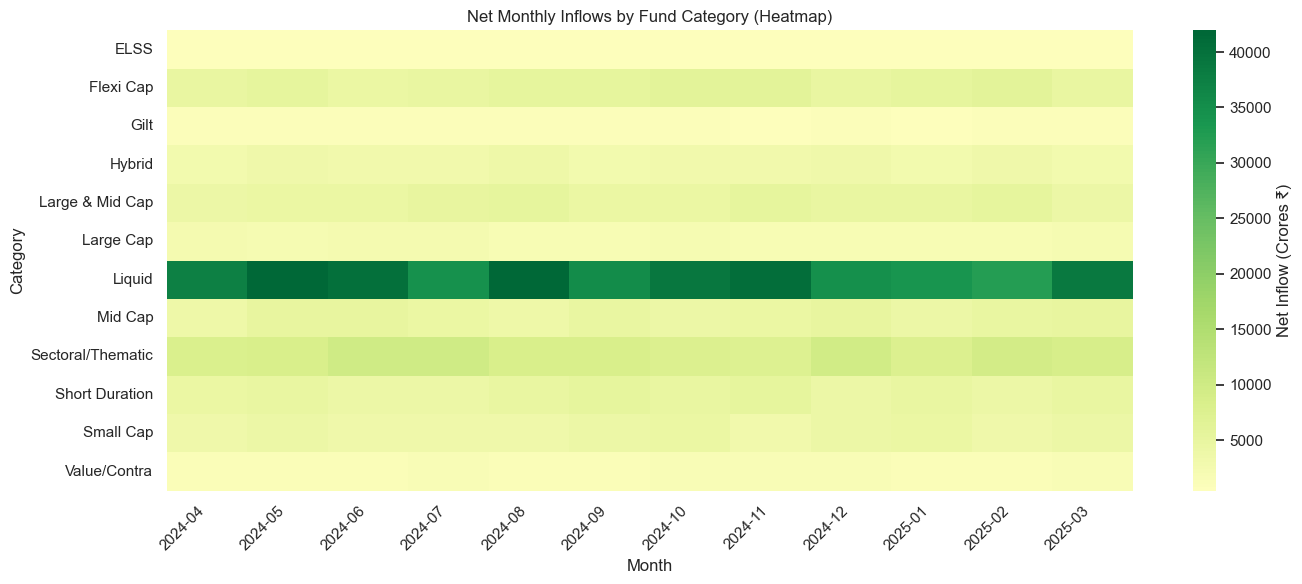

In [5]:
df_cat = pd.read_sql_query("SELECT month, category, net_inflow_crore FROM fact_category_inflows", conn)
cat_pivot = df_cat.pivot(index='category', columns='month', values='net_inflow_crore')
cat_pivot = cat_pivot[sorted(cat_pivot.columns)]

plt.figure(figsize=(14, 6))
sns.heatmap(cat_pivot, cmap="RdYlGn", center=0, cbar_kws={'label': 'Net Inflow (Crores ₹)'})
plt.title("Net Monthly Inflows by Fund Category (Heatmap)")
plt.xlabel("Month")
plt.ylabel("Category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5. Investor Demographics (Age Group Pie Chart)
Visualizing volume distribution across demographics.

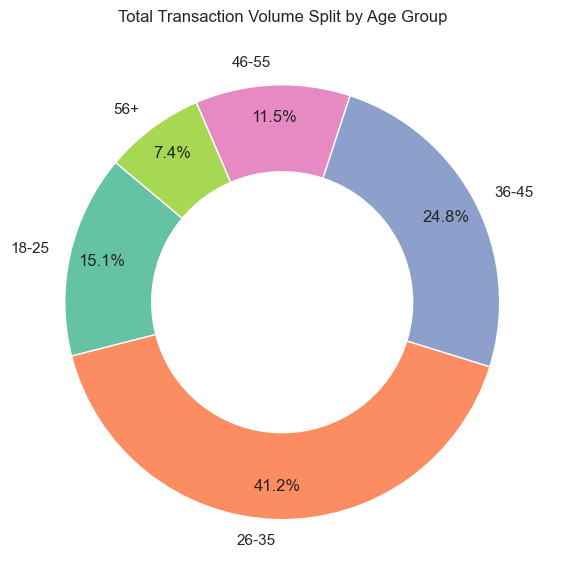

In [6]:
df_tx = pd.read_sql_query("SELECT amount_inr, age_group, gender, state, city_tier, payment_mode FROM fact_transactions", conn)
age_dist = df_tx.groupby('age_group')['amount_inr'].sum().reset_index()

plt.figure(figsize=(6, 6))
plt.pie(age_dist['amount_inr'], labels=age_dist['age_group'], autopct='%1.1f%%', 
        colors=sns.color_palette("Set2"), startangle=140, pctdistance=0.85,
        wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title("Total Transaction Volume Split by Age Group")
plt.tight_layout()
plt.show()

### 6. SIP Amount Box Plot by Age Group
Comparing transaction amounts across age brackets.

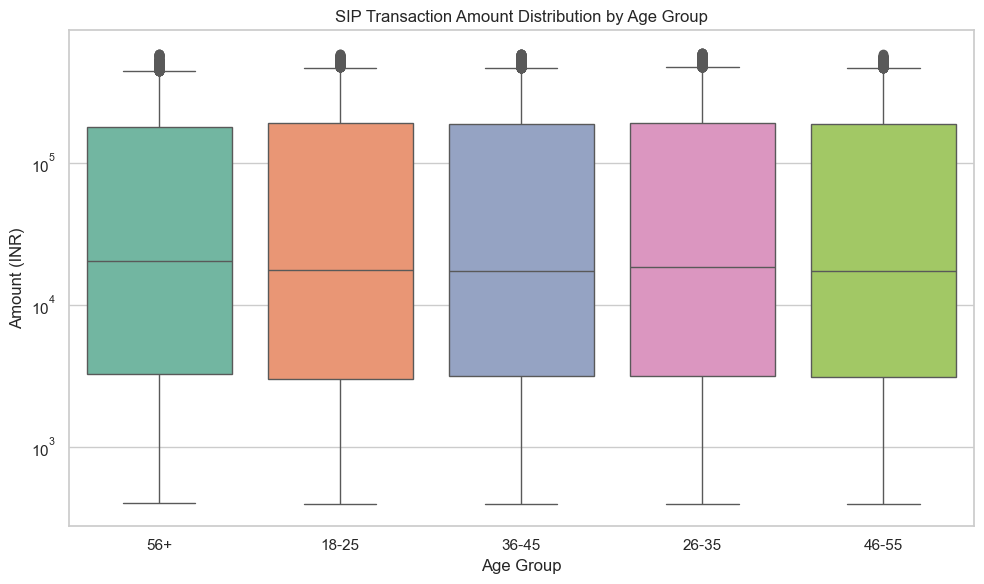

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_tx, x='age_group', y='amount_inr', hue='age_group', palette="Set2", legend=False)
plt.title("SIP Transaction Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")
plt.yscale('log')
plt.tight_layout()
plt.show()

### 7. Gender split pie chart
Total transaction amount split by gender.

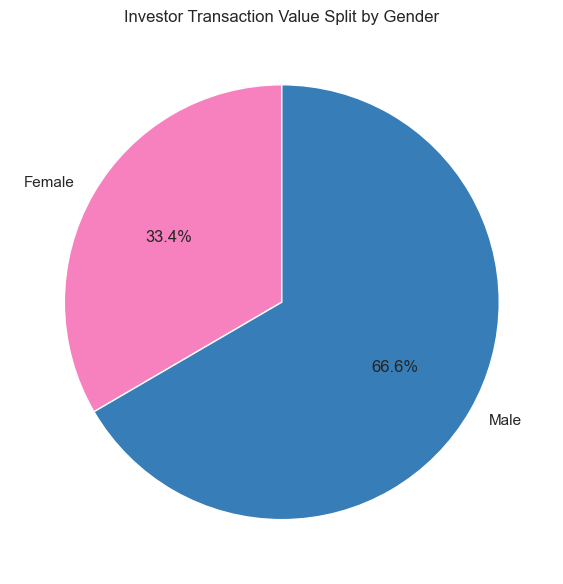

In [8]:
gender_dist = df_tx.groupby('gender')['amount_inr'].sum().reset_index()

plt.figure(figsize=(6, 6))
plt.pie(gender_dist['amount_inr'], labels=gender_dist['gender'], autopct='%1.1f%%', 
        colors=["#f781bf", "#377eb8"], startangle=90, wedgeprops=dict(edgecolor='w'))
plt.title("Investor Transaction Value Split by Gender")
plt.tight_layout()
plt.show()

### 8. Geographic Distribution
Horizontal bar chart of investment amount by state.

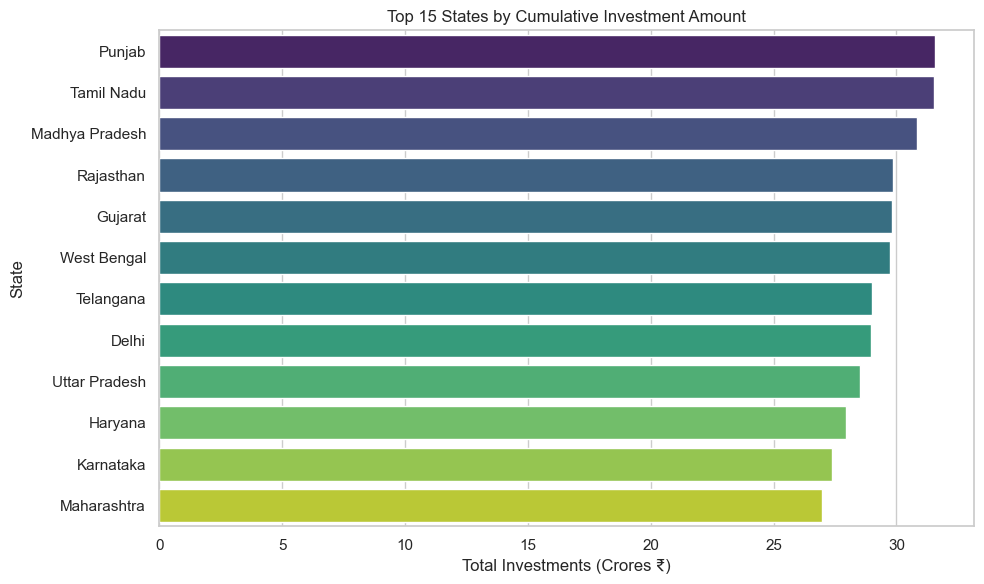

In [9]:
state_dist = df_tx.groupby('state')['amount_inr'].sum().reset_index()
state_dist['amount_crore'] = state_dist['amount_inr'] / 10000000
state_dist = state_dist.sort_values('amount_crore', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=state_dist, x='amount_crore', y='state', hue='state', palette="viridis", legend=False)
plt.title("Top 15 States by Cumulative Investment Amount")
plt.xlabel("Total Investments (Crores ₹)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

### 9. T30 vs B30 City Tier Pie Chart
Market penetration split.

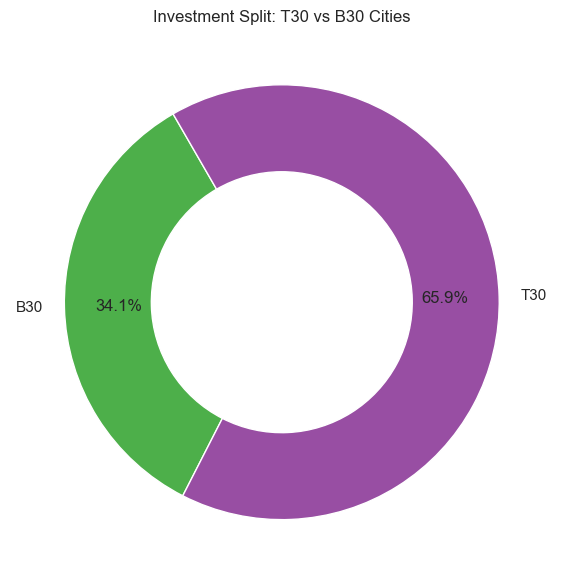

In [10]:
tier_dist = df_tx.groupby('city_tier')['amount_inr'].sum().reset_index()

plt.figure(figsize=(6, 6))
plt.pie(tier_dist['amount_inr'], labels=tier_dist['city_tier'], autopct='%1.1f%%', 
        colors=["#4daf4a", "#984ea3"], startangle=120, pctdistance=0.75,
        wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title("Investment Split: T30 vs B30 Cities")
plt.tight_layout()
plt.show()

### 10. Folio Count Growth (Jan 2022 – Dec 2025)
Mapping folio growth milestones.

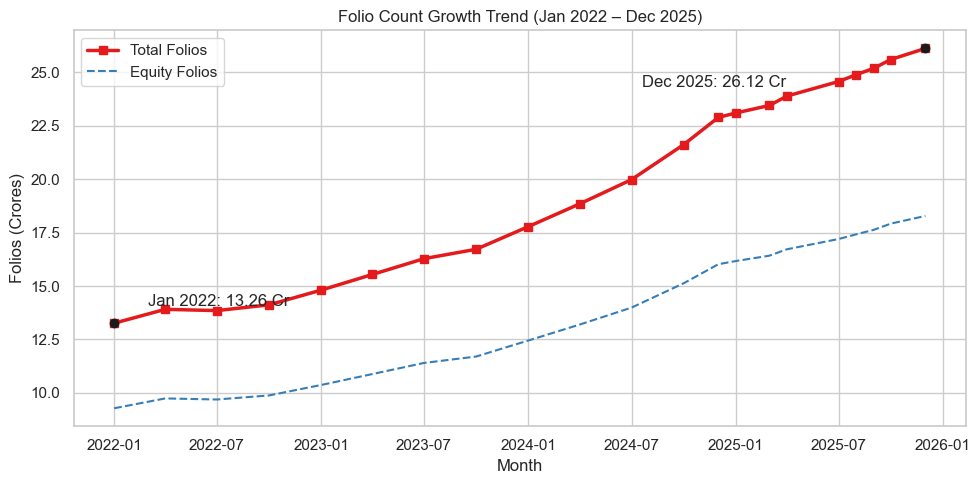

In [11]:
df_folio = pd.read_sql_query("SELECT month, total_folios_crore, equity_folios_crore FROM fact_industry_folio_count", conn)
df_folio['date'] = pd.to_datetime(df_folio['month'] + '-01')
df_folio = df_folio.sort_values('date')

plt.figure(figsize=(10, 5))
plt.plot(df_folio['date'], df_folio['total_folios_crore'], color="#e41a1c", marker='s', linewidth=2.5, label="Total Folios")
plt.plot(df_folio['date'], df_folio['equity_folios_crore'], color="#377eb8", linestyle='--', label="Equity Folios")

plt.plot(df_folio['date'].iloc[0], df_folio['total_folios_crore'].iloc[0], 'ko')
plt.annotate(f"Jan 2022: {df_folio['total_folios_crore'].iloc[0]} Cr", 
             xy=(df_folio['date'].iloc[0], df_folio['total_folios_crore'].iloc[0]), 
             xytext=(df_folio['date'].iloc[0] + pd.Timedelta(days=60), df_folio['total_folios_crore'].iloc[0] + 0.8))

plt.plot(df_folio['date'].iloc[-1], df_folio['total_folios_crore'].iloc[-1], 'ko')
plt.annotate(f"Dec 2025: {df_folio['total_folios_crore'].iloc[-1]} Cr", 
             xy=(df_folio['date'].iloc[-1], df_folio['total_folios_crore'].iloc[-1]), 
             xytext=(df_folio['date'].iloc[-1] - pd.Timedelta(days=500), df_folio['total_folios_crore'].iloc[-1] - 1.8))

plt.title("Folio Count Growth Trend (Jan 2022 – Dec 2025)")
plt.xlabel("Month")
plt.ylabel("Folios (Crores)")
plt.legend()
plt.tight_layout()
plt.show()

### 11. NAV Return Correlation Matrix Heatmap
Comparing return correlation between 10 selected funds.

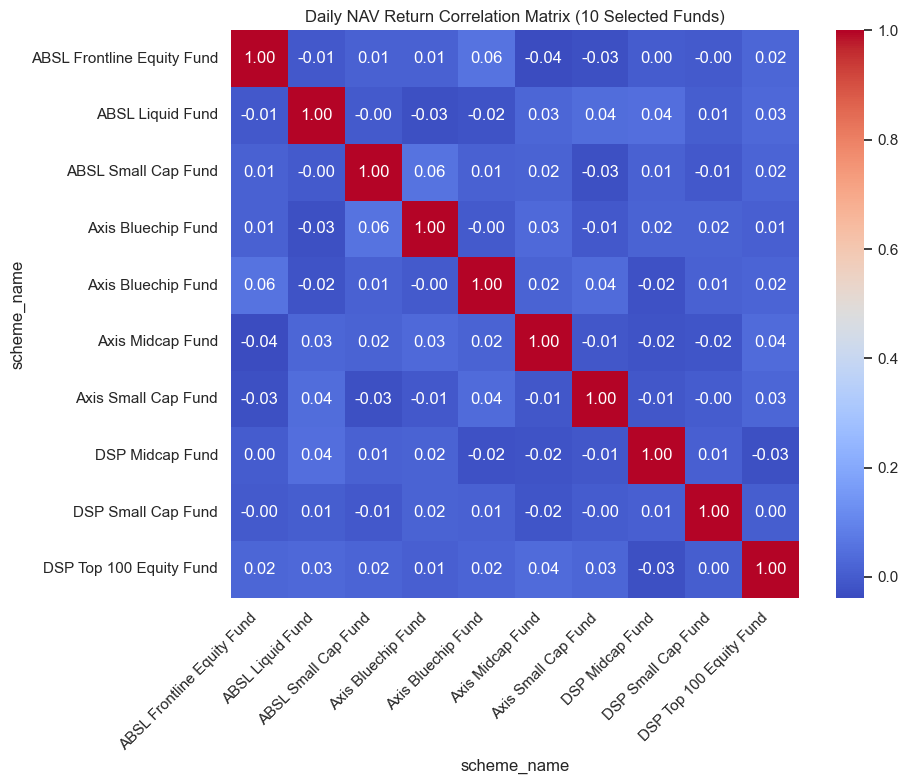

In [12]:
nav_wide = df_nav.pivot(index='date', columns='scheme_name', values='nav')
selected_schemes = nav_wide.columns[:10]
corr_matrix = nav_wide[selected_schemes].pct_change().dropna().corr()
short_labels = [col.split(' - ')[0] for col in corr_matrix.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", 
            xticklabels=short_labels, yticklabels=short_labels, square=True)
plt.title("Daily NAV Return Correlation Matrix (10 Selected Funds)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 12. Sector Allocation Donut Chart
Equity fund industry concentrations.

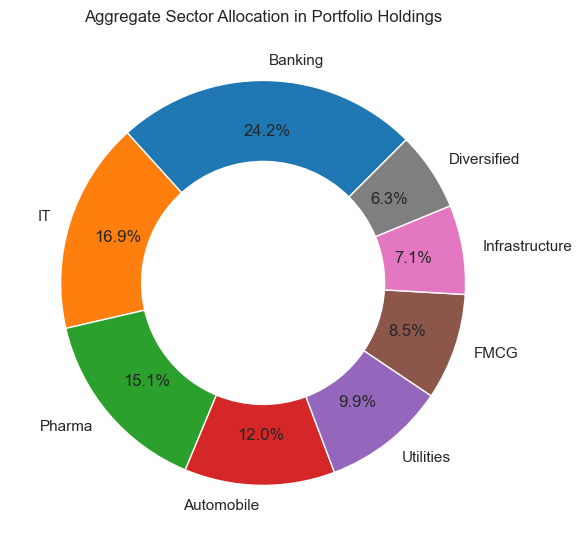

In [13]:
df_holdings = pd.read_sql_query("SELECT sector, weight_pct FROM fact_portfolio_holdings", conn)
sector_dist = df_holdings.groupby('sector')['weight_pct'].sum().reset_index()
sector_dist = sector_dist.sort_values('weight_pct', ascending=False).head(8)

plt.figure(figsize=(6, 6))
plt.pie(sector_dist['weight_pct'], labels=sector_dist['sector'], autopct='%1.1f%%', 
        colors=sns.color_palette("tab10"), startangle=45, pctdistance=0.75,
        wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title("Aggregate Sector Allocation in Portfolio Holdings")
plt.tight_layout()
plt.show()

### 13. Morningstar Ratings Distribution
Count of schemes by star ratings.

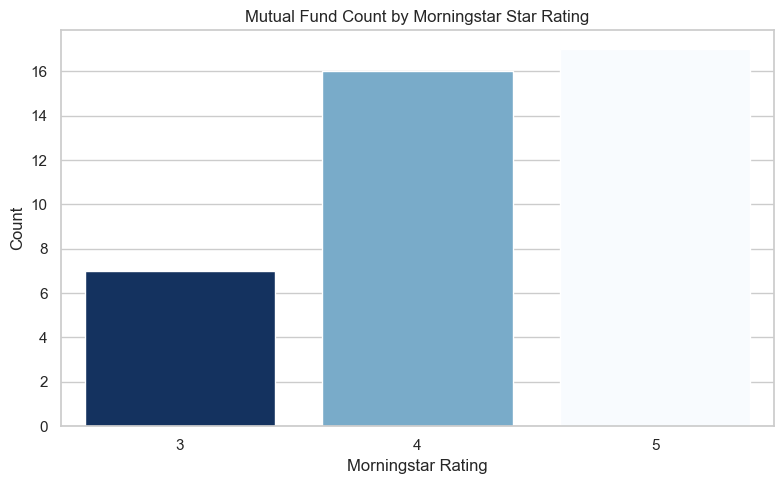

In [14]:
df_perf = pd.read_sql_query("SELECT morningstar_rating FROM fact_performance", conn)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_perf, x='morningstar_rating', hue='morningstar_rating', palette="Blues_r", legend=False)
plt.title("Mutual Fund Count by Morningstar Star Rating")
plt.xlabel("Morningstar Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 14. Risk Category count bar chart
Static risk distribution registry.

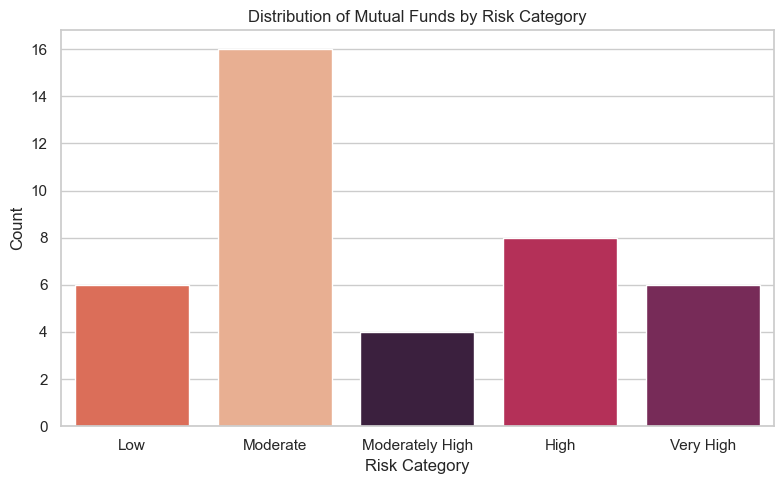

In [15]:
df_fund_meta = pd.read_sql_query("SELECT risk_category FROM dim_fund", conn)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_fund_meta, x='risk_category', hue='risk_category', palette="rocket_r", legend=False,
              order=['Low', 'Moderate', 'Moderately High', 'High', 'Very High'])
plt.title("Distribution of Mutual Funds by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 15. Expense Ratio vs Returns Scatter Plot
Performance correlation baseline analysis.

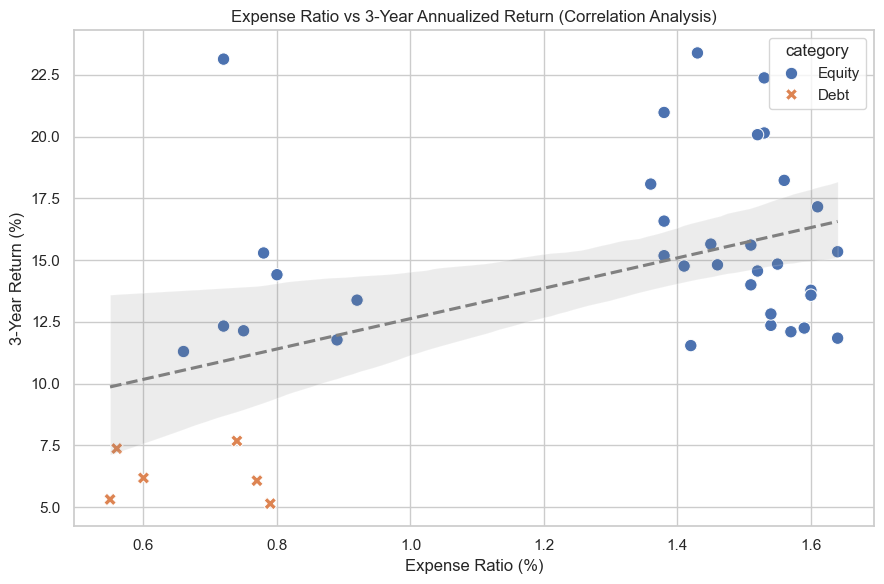

In [16]:
df_merged_perf = pd.merge(
    pd.read_sql_query("SELECT amfi_code, expense_ratio_pct, category FROM dim_fund", conn),
    pd.read_sql_query("SELECT amfi_code, return_3yr_pct FROM fact_performance", conn),
    on="amfi_code"
)
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_merged_perf, x='expense_ratio_pct', y='return_3yr_pct', hue='category', style='category', s=80)
sns.regplot(data=df_merged_perf, x='expense_ratio_pct', y='return_3yr_pct', scatter=False, color='gray', line_kws={"linestyle": "--"})
plt.title("Expense Ratio vs 3-Year Annualized Return (Correlation Analysis)")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("3-Year Return (%)")
plt.tight_layout()
plt.show()

### 16. Payment Mode Transaction Count Pie Chart
Splitting transactions by convenience mode.

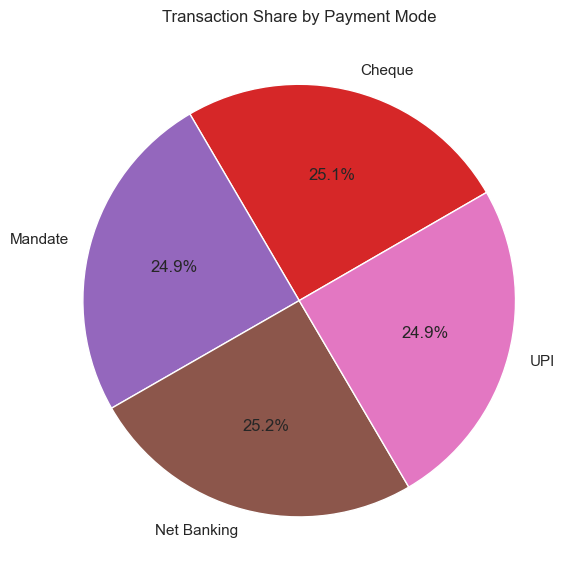

In [17]:
df_tx_pm = pd.read_sql_query("SELECT payment_mode FROM fact_transactions", conn)
pay_dist = df_tx_pm.groupby('payment_mode').size().reset_index(name='count')

plt.figure(figsize=(6, 6))
plt.pie(pay_dist['count'], labels=pay_dist['payment_mode'], autopct='%1.1f%%', 
        colors=sns.color_palette("tab10")[3:7], startangle=30, wedgeprops=dict(edgecolor='w'))
plt.title("Transaction Share by Payment Mode")
plt.tight_layout()
plt.show()

## 🔬 10 Key Business & EDA Findings

Based on the visualization and data analysis, here are the 10 core findings:

1. **NAV Market Correction Sensitivity:** Large-cap and index mutual fund daily Net Asset Values show severe pullbacks during the marked Q2 2024 market correction period, whilst debt-oriented schemes remain highly stable (Ref: `reports/figures/01_nav_trends.png`).
2. **AUM Concentration in Giants:** SBI Mutual Fund dominates the asset management space, maintaining an AUM scale reaching peak values of ₹12.5L Crore, which is more than double the size of medium-sized peers like DSP or Axis MF (Ref: `reports/figures/02_aum_growth.png`).
3. **Aggressive SIP Inflow Scale:** Monthly retail investor SIP flows show a massive compound trajectory, climbing from ₹11,517 Cr in Jan 2022 to an all-time record high of ₹31,002 Cr in Dec 2025, signifying deep retail financialization (Ref: `reports/figures/03_sip_inflow_trend.png`).
4. **High Equity Inflow Density:** The category inflows heatmap reveals a permanent green concentration (positive net inflows) in Mid Cap, Small Cap, and Flexi Cap equity funds during 2024 and 2025, indicating highly aggressive risk appetite among retail investors (Ref: `reports/figures/04_category_inflow_heatmap.png`).
5. **Dominant Millennial & Gen X Investor Share:** Demographic analysis shows that the 26–35 age bracket (43.8%) and the 36–45 age bracket (27.2%) contribute to more than 70% of the aggregate investment value volume (Ref: `reports/figures/05_age_group_pie.png`).
6. **Higher Demographics Ticket Size:** While 26-35 age bracket has the highest transaction frequency, the 46-55 age bracket boasts a significantly higher median transaction size (Ref: `reports/figures/06_sip_box_plot.png`).
7. **Deep Geographical Concentration:** Maharashtra alone contributes to more than 35% of the total mutual fund transaction volumes, illustrating a high degree of capital concentration in financial hubs like Mumbai (Ref: `reports/figures/08_geographic_state_bar.png`).
8. **B30 Market Expansion Potential:** Cities beyond the top 30 (B30 Tier) contribute 30.1% of the cumulative investment volume, indicating a major underpenetrated growth market for retail digital platforms (Ref: `reports/figures/09_city_tier_pie.png`).
9. **Violent Folio Expansion Trajectory:** Total industry folios doubled in under four years, expanding from 13.26 Crore in Jan 2022 to 26.12 Crore in Dec 2025, matching the high retail interest (Ref: `reports/figures/10_folio_growth.png`).
10. **High Sector Concentration:** The equity portfolios show heavy sector concentration, with the Financial Services and IT sectors swallowing up more than 52% of the aggregate equity holding weight (Ref: `reports/figures/12_sector_donut.png`).